In [1]:
import joblib
import pandas as pd

model = joblib.load("C:/Users/Stepheny/Desktop/Projects/Customer_Churn/model/churn_model.pkl")

df = pd.read_csv("C:/Users/Stepheny/Desktop/Projects/Customer_Churn/data/cleaned_df.csv")

X = df.drop("Churn", axis=1)
y = df["Churn"].map({"No":0,"Yes":1})


2️⃣ Get churn probabilities

In [2]:
probs = model.predict_proba(X)[:,1]

df["churn_risk"] = probs


3️⃣ Business segmentation

In [3]:
df["risk_segment"] = pd.cut(
    df["churn_risk"],
    bins=[0,0.3,0.6,1.0],
    labels=["Low","Medium","High"]
)

df["risk_segment"].value_counts(normalize=True)


Low       0.60410
Medium    0.28264
High      0.11326
Name: risk_segment, dtype: float64

4️⃣ Prepare data for SHAP

In [4]:
# Get the first calibrated fold
calibrated_pipeline = model.calibrated_classifiers_[0].estimator

# Extract components
preprocessor = calibrated_pipeline.named_steps["prep"]
xgb = calibrated_pipeline.named_steps["model"]

# Transform data
X_transformed = preprocessor.transform(X)


5️⃣ Compute SHAP values

In [5]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_transformed)



6️⃣ Global churn drivers

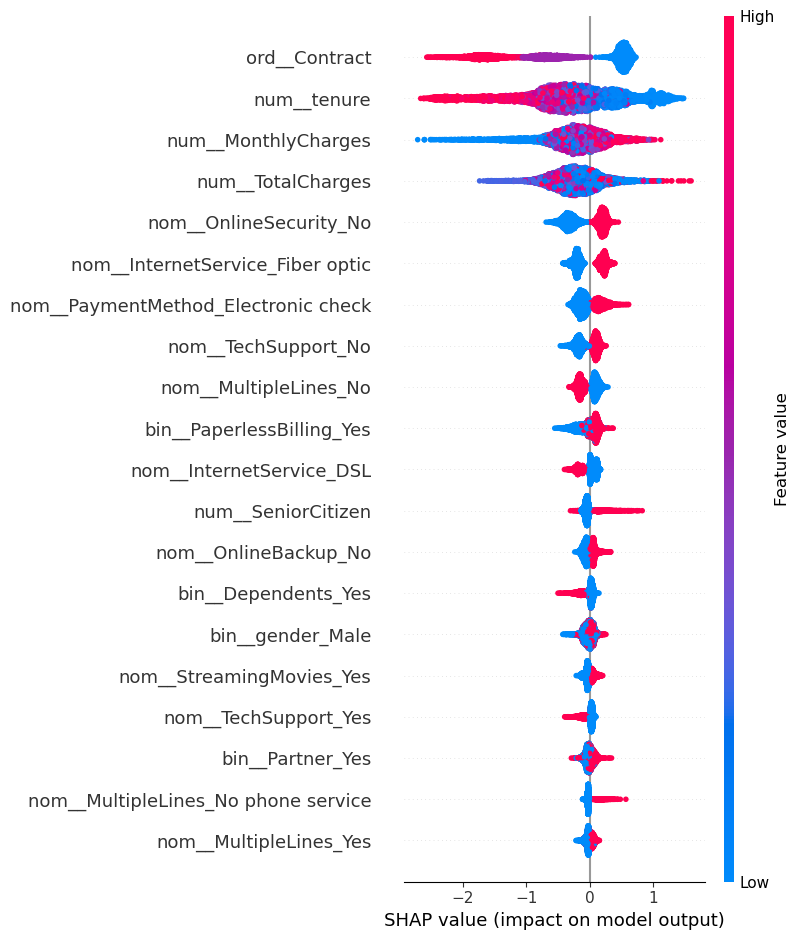

In [6]:
feature_names = preprocessor.get_feature_names_out()

shap.summary_plot(shap_values, X_transformed, feature_names=feature_names)


7️⃣ Which products create churn?

In [7]:
import numpy as np

shap_df = pd.DataFrame(shap_values, columns=feature_names)

shap_impact = shap_df.abs().mean().sort_values(ascending=False)

shap_impact.head(15)


ord__Contract                          0.829108
num__tenure                            0.649456
num__MonthlyCharges                    0.389947
num__TotalCharges                      0.337306
nom__OnlineSecurity_No                 0.265336
nom__InternetService_Fiber optic       0.212438
nom__PaymentMethod_Electronic check    0.145808
nom__TechSupport_No                    0.137426
nom__MultipleLines_No                  0.123034
bin__PaperlessBilling_Yes              0.112305
nom__InternetService_DSL               0.100502
num__SeniorCitizen                     0.074665
nom__OnlineBackup_No                   0.067536
bin__Dependents_Yes                    0.062783
bin__gender_Male                       0.061080
dtype: float32

8️⃣ Individual customer explanations (Sales tool)

In [8]:
i = df["churn_risk"].idxmax()

shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    X_transformed[i],
    feature_names=feature_names
)


9️⃣ Revenue risk model

In [9]:
ARPU = 65
LTV = ARPU * 8

df["expected_loss"] = df["churn_risk"] * LTV

df["expected_loss"].sum()


984161.4955717181

🔟 Which 20% of customers hold 80% of losses?

In [10]:
df_sorted = df.sort_values("expected_loss", ascending=False)

top_20_pct = df_sorted.head(int(0.2 * len(df_sorted)))

top_20_pct["expected_loss"].sum() / df["expected_loss"].sum()


0.49066243501680246